In [4]:
# models: clustering [kmeans, (with lda, svd), svm], neural networks w2v, logistic reg
# func eval_kmeans/svm (model, train,test) = acc, roc 
# def vectorize() = tfidf, counter, bow, embeddings
# pre processing -> vectorize/embeddings -> models 

In [2]:
# imports
import matplotlib.pyplot as plt
import os.path
import codecs
import numpy as np
import string
from preprocessing_class import Preprocessing, load_movies
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split,KFold
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import accuracy_score
from extraction_vocab_bow import basic_bow_exploration
from nltk.corpus import stopwords

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# load dataset
path = "./Dataset/movies1000/"
alltxts,alllabs = load_movies(path)
alltxts, alllabs = np.array(alltxts), np.array(alllabs)

# bag of words, with simple préprocessing (lowercase, no punctuation, no URLS)
prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )

cleaned_txts = [prep.process(text) for text in alltxts]

In [5]:
print(len(cleaned_txts),len(alltxts))

2000 2000


In [9]:
alltxts[0], cleaned_txts[0]

(np.str_(' " holy man " boasts a sweet , gentle , comic performance from an unusually subdued eddie murphy and a few moderately funny skits . \nunfortunately , to get to the good stuff you have to sit through a painfully long set-up , loads of tedious filler , interminable shots of jeff goldblum stammering and twitching , a superfluous romantic subplot and quite possibly the most annoying performance of robert loggia\'s career . \nif ever a movie screamed " wait for video so you can fast-forward through all the dull and annoying parts , " this is it . \neddie murphy plays g , a robed nomadic pilgrim wandering the land enjoying the moment and spreading his spiritual message . \na chance meeting with ricky hayman ( goldblum ) , a stressed-out executive of a home-shopping channel , and kate newell ( kelly preston ) , a no-nonsense media analyst , results in physical injury to g . quicker than you can say " the odd couple , " g ends up rooming with an extremely leery ricky . \nafter some s

2000 documents
taille origine du vocab: 39363 mots total
['00' '000' '0009f' ... 'zwigoff' 'zycie' 'zzzzzzz'] 

vocab avec les 100 mots plus frequents :
['about' 'after' 'all' 'also' 'an' 'and' 'any' 'are' 'as' 'at' 'be'
 'because' 'been' 'but' 'by' 'can' 'character' 'characters' 'could' 'do'
 'does' 'even' 'film' 'films' 'first' 'for' 'from' 'get' 'good' 'had'
 'has' 'have' 'he' 'her' 'him' 'his' 'how' 'if' 'in' 'into' 'is' 'it'
 'its' 'just' 'life' 'like' 'little' 'make' 'more' 'most' 'movie' 'much'
 'no' 'not' 'of' 'off' 'on' 'one' 'only' 'or' 'other' 'out' 'over'
 'people' 'plot' 'really' 'see' 'she' 'so' 'some' 'story' 'than' 'that'
 'the' 'their' 'them' 'then' 'there' 'they' 'this' 'time' 'to' 'too' 'two'
 'up' 'very' 'was' 'way' 'we' 'well' 'what' 'when' 'where' 'which' 'while'
 'who' 'will' 'with' 'would' 'you'] 

100 mots avec la plus grande frequence doc:
['the' 'of' 'and' 'to' 'is' 'in' 'it' 'that' 'with' 'for' 'as' 'but'
 'this' 'on' 'an' 'by' 'are' 'one' 'be' 'his' 'film' 

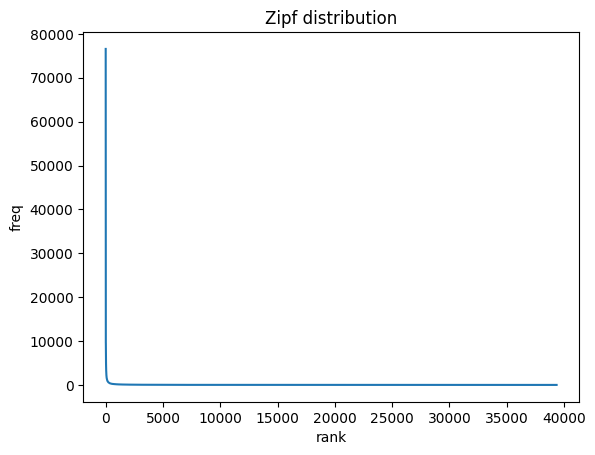

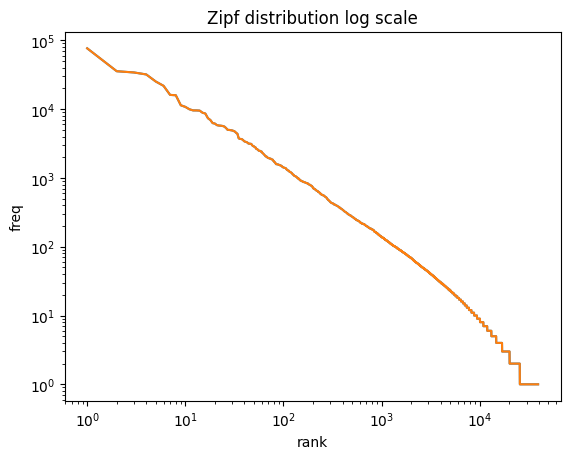


100 bigrammes les plus freq:
['about the' 'all of' 'all the' 'and his' 'and it' 'and the' 'as the'
 'as well' 'at least' 'at the' 'but it' 'but the' 'by the' 'could have'
 'film is' 'for the' 'from the' 'going to' 'has been' 'have been'
 'have to' 'he has' 'he is' 'if you' 'in his' 'in the' 'in this'
 'into the' 'is an' 'is not' 'is one' 'is that' 'is the' 'it is' 'it was'
 'kind of' 'like the' 'lot of' 'more than' 'most of' 'movie is'
 'of course' 'of his' 'of the' 'of them' 'of this' 'on the' 'one of'
 'out of' 'over the' 'played by' 'seems to' 'some of' 'that he' 'that is'
 'that it' 'that the' 'the audience' 'the best' 'the characters' 'the end'
 'the film' 'the first' 'the most' 'the movie' 'the only' 'the other'
 'the plot' 'the rest' 'the same' 'the story' 'the two' 'the way'
 'the world' 'there are' 'there is' 'they are' 'they re' 'this film'
 'this is' 'this movie' 'to be' 'to do' 'to get' 'to have' 'to make'
 'to see' 'to the' 'trying to' 'up to' 'want to' 'when he' 'when th

In [ ]:
# bow vocab exploring
basic_bow_exploration(cleaned_txts,lang="english")

**(b) Dictionary processing, restricting vocabulary size: corpus-specific stopwords** => max_df + suppress rare words (min_df) + max_features

- **max_df:** float in range [0.0, 1.0] or int, default=1.0
When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

- **min_df:** float in range [0.0, 1.0] or int, default=1
When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold. This value is also called cut-off in the literature. If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

- **max_features:** int or None, default=None
If not None, build a vocabulary that only consider the top max_features ordered by term frequency across the corpus.
This parameter is ignored if vocabulary is not None.

In [ ]:
# vectorization  

final_stopwords_list = stopwords.words('english')

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=1, min_df=1):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [ ]:
count_vect = build_vectorizer(name="count")
countX = vectorize_txts(cleaned_txts,count_vect)
X_train, X_test, y_train, y_test  = train_test_split(countX, alllabs, test_size=0.2, random_state=10, shuffle=True)

In [41]:
tfidf_vect = build_vectorizer(name="tfidf")
tfidfX = vectorize_txts(cleaned_txts,tfidf_vect)
X_train, X_test, y_train, y_test  = train_test_split(tfidfX, alllabs, test_size=0.2, random_state=10, shuffle=True)


In [42]:
print(X_train.shape,X_test.shape,len(y_train),len(y_test))

(1600, 12309) (400, 12309) 1600 400


In [ ]:
## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 8, max_iter = 1000,penalty='l2',loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter)

def pipeline(model,X_train,y_train):
    model.fit(X_train,y_train)
    ypred_train = model.predict(X_train)
    ypred = model.predict(X_test)
    print(accuracy_score(y_train,ypred_train),accuracy_score(y_test,ypred))
    return model


In [46]:
kmeans = build_model("kmeans",n_clusters=2)
kmeans = pipeline(kmeans)

linear_svm = build_model("linear_svm")
linear_svm = pipeline(linear_svm)

svm = build_model("svm")
svm = pipeline(svm)

logreg = build_model("logreg")
logreg = pipeline(logreg)


0.50375 0.4875
0.98125 0.5125


/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.98125 0.4975
0.9775 0.4875


In [ ]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

text = [t.split() for t in alltxts] # p is the class

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)
# sauvegarder modèle !!!!!
w2v.save("W2v-movies.dat")
# pour load
# w2v = gensim.models.Word2Vec.load("W2v-movies.dat")


def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
            
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)





2026-03-12 16:13:23,911 : INFO : collecting all words and their counts
2026-03-12 16:13:23,912 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-12 16:13:24,179 : INFO : collected 50920 word types from a corpus of 1492681 raw words and 2000 sentences
2026-03-12 16:13:24,181 : INFO : Creating a fresh vocabulary
2026-03-12 16:13:24,232 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 15283 unique words (30.01% of original 50920, drops 35637)', 'datetime': '2026-03-12T16:13:24.232027', 'gensim': '4.4.0', 'python': '3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-14-generic-x86_64-with-glibc2.39', 'event': 'prepare_vocab'}
2026-03-12 16:13:24,233 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 1435031 word corpus (96.14% of original 1492681, drops 57650)', 'datetime': '2026-03-12T16:13:24.232991', 'gensim': '4.4.0', 'python': '3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]', 'p

In [ ]:

from sklearn import preprocessing

X = [embed(text, w2v) for text in alltxts]
#Xtest = [vectorize(text, w2v) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
#Xtest_scaled = scaler.transform(Xtest)



In [55]:
X_scaled.shape,len(alllabs)

((2000, 100), 2000)

In [ ]:
logreg = build_model("logreg")

def pipe(model,X_train,y_train):
    model.fit(X_train,y_train)
    ypred_train = model.predict(X_train)
    #ypred = model.predict(X_test)
    print(accuracy_score(y_train,ypred_train))#,accuracy_score(y_test,ypred))
    #print(model.score(X_train,y_train))
    #print(model.score(X_test,y_test))
    return model

logreg = pipe(logreg,X_scaled,alllabs)


0.6595


In [58]:
import gensim.downloader as api
from gensim.models import KeyedVectors

bload = False
fname = "word2vec-google-news-300"
sdir = "" # Change

wv_pre_trained = api.load(fname)
wv_pre_trained.save(sdir+fname+".dat")


[==================================================] 100.0% 1662.8/1662.8MB downloaded


2026-03-12 16:40:21,743 : INFO : word2vec-google-news-300 downloaded
2026-03-12 16:40:21,745 : INFO : loading projection weights from /home/alant/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz
2026-03-12 16:41:07,595 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (3000000, 300) matrix of type float32 from /home/alant/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz', 'binary': True, 'encoding': 'utf8', 'datetime': '2026-03-12T16:41:07.594987', 'gensim': '4.4.0', 'python': '3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-14-generic-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}
2026-03-12 16:41:07,596 : INFO : KeyedVectors lifecycle event {'fname_or_handle': 'word2vec-google-news-300.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-03-12T16:41:07.596316', 'gensim': '4.4.0', 'python': '3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-14-

In [60]:
fname = "word2vec-google-news-300.dat"
w2v = gensim.models.keyedvectors.KeyedVectors.load(fname)

2026-03-12 16:43:40,421 : INFO : loading KeyedVectors object from word2vec-google-news-300.dat


2026-03-12 16:43:42,464 : INFO : loading vectors from word2vec-google-news-300.dat.vectors.npy with mmap=None
2026-03-12 16:43:43,542 : INFO : KeyedVectors lifecycle event {'fname': 'word2vec-google-news-300.dat', 'datetime': '2026-03-12T16:43:43.542561', 'gensim': '4.4.0', 'python': '3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-14-generic-x86_64-with-glibc2.39', 'event': 'loaded'}


In [ ]:
def embed(text, w2v, mean=False, min = False, max = False): # only for embeddings
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.key_to_index[word] 
            vec.append(w2v[idx])
            
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)

X = [embed(text, w2v) for text in alltxts]
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)


logreg = build_model("logreg")
def pipe(model,X_train,y_train):
    model.fit(X_train,y_train)
    ypred_train = model.predict(X_train)
    #ypred = model.predict(X_test)
    print(accuracy_score(y_train,ypred_train))#,accuracy_score(y_test,ypred))
    #print(model.score(X_train,y_train))
    #print(model.score(X_test,y_test))
    return model

logreg = pipe(logreg,X_scaled,alllabs)


0.637


In [ ]:
# naive bayes
from sklearn.naive_bayes import MultinomialNB,GaussianNB,ComplementNB,BernoulliNB #complement for imblalanced dataset
mnb = MultinomialNB().fit(x_train, y_train)
print("score on test: " + str(mnb.score(x_test, y_test)))


# rnn
# decision trees (bagging boosting)

# dans .py
# preprocess ok
# pipeline vectorizer return model deja fait a clean etc
# pipeline embed pretrain + trained from data return model

# dans evaluation.py
# cross valid output scores, plots, prend model, train (val fait par cross) 
# evaluer sur tout train, test
# final predict test dataset to submit  


# savoir ce que jai tester, dans ipynb, rank les 7 meilleurs, 

